
# Transformer + JADE Hyperparameter Optimization (Colab)

Este cuaderno unifica **modelo1_mejorado** (Transformer) y **optim_jade** (JADE) para entrenar y optimizar un clasificador de secuencias (por ejemplo, gestos o poses).

**Qué hace:**
1. Monta Google Drive y carga `gesture_dataset12clases_5aum.npy`.
2. Define el modelo Transformer con *positional encoding* seno/cos.
3. Entrena y evalúa con métricas (accuracy y macro-F1 en validación).
4. Ejecuta **JADE** (DE/current-to-pbest/1 con archivo) para optimizar hiperparámetros.
5. Re-entrena con los mejores hiperparámetros y guarda artefactos en Drive.
6. Ejecuta **NL-SHADE** para optimizar hiperparámetros.
7. Re-entrena con los mejores hiperparámetros y guarda artefactos en Drive.
8. Genera Gráficas comparativas de F1, tiempo e hiperparámetros.
9. Genera Gráficas comparativas G1, G2, G3 y G4.






In [1]:
# Montaje robusto de Google Drive en Colab
from google.colab import drive
import os, shutil, time

MOUNT_POINT = "/content/drive"

# 1) Si estaba montado, desmonta
try:
    drive.flush_and_unmount()
    time.sleep(0.5)
except Exception:
    pass  # no estaba montado

# 2) Si la carpeta existe y NO es un montaje, bórrala para que quede vacía
if os.path.exists(MOUNT_POINT) and not os.path.ismount(MOUNT_POINT):
    try:
        shutil.rmtree(MOUNT_POINT)
    except Exception:
        pass

# 3) Monta (forzando el remount por si Colab quedó con estado raro)
drive.mount(MOUNT_POINT, force_remount=True)


Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive


In [2]:
#@title 1) Montar Google Drive y definir rutas
from google.colab import drive
# Unmount if already mounted and not empty
try:
  drive.flush_and_unmount()
except ValueError:
  pass # Already unmounted or empty
drive.mount('/content/drive/')

#@markdown Ruta a tu archivo de datos en Drive
DATA_PATH = "/content/drive/MyDrive/Bio_inspired_algorithms/gesture_dataset12clases_5aum.npy"  #@param {type:"string"}
#@markdown Carpeta de salida para guardar resultados (modelos, curvas, logs)
OUT_DIR = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"               #@param {type:"string"}

import os
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

Mounted at /content/drive/
OUT_DIR: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs


In [3]:

#@title 2) Instalar dependencias
!pip -q install pandas scikit-learn matplotlib


In [4]:

#@title 3) Imports base y configuración de GPU
import os, time, math, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from datetime import datetime

print("TensorFlow:", tf.__version__)
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

# Activar mixed precision si hay GPU (acelera y ahorra VRAM)
try:
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision activada.")
except Exception as e:
    print("Mixed precision no disponible o no activada:", e)


TensorFlow: 2.19.0
Num GPUs Available: 1
Mixed precision activada.


In [5]:
import numpy as np
data = np.load(DATA_PATH, allow_pickle=True)
print(type(data))
try:
    print(data.item().keys())
except:
    print("Contenido:", data)

<class 'numpy.ndarray'>
dict_keys(['data', 'labels'])


In [6]:

#@title 4) Cargar dataset (npz/npy) desde Drive (robusto a 'data/labels' o 'X/y')
import numpy as np

def load_dataset(path):
    data = np.load(path, allow_pickle=True)

    # Caso .npz con varios arrays
    if isinstance(data, np.lib.npyio.NpzFile):
        keys = list(data.files)
        # Heurística de nombres
        def pick(keys, candidates):
            for c in candidates:
                for k in keys:
                    if k.lower() == c:
                        return k
            return None

        kX = pick(keys, ['x','data','features','arr_0'])
        ky = pick(keys, ['y','labels','target','arr_1'])
        kc = pick(keys, ['classes','class_names','label_names'])

        assert kX is not None and ky is not None, f"No encuentro X/y en {keys}"
        X = data[kX].astype('float32')
        y = data[ky].astype('int64')
        classes = data[kc] if kc in keys else None
        return X, y, classes

    # Caso .npy con dict
    if hasattr(data, 'item'):
        d = data.item()
        keys = set(d.keys())
        # Soporta 'X/y' y 'data/labels'
        if 'X' in d and 'y' in d:
            X = d['X'].astype('float32')
            y = d['y'].astype('int64')
        elif 'data' in d and 'labels' in d:
            X = d['data'].astype('float32')
            y = d['labels'].astype('int64')
        else:
            # Intento genérico: toma los dos primeros valores
            vals = list(d.values())
            if len(vals) < 2:
                raise ValueError(f"Diccionario no compatible. Claves: {keys}")
            X = np.array(vals[0], dtype='float32')
            y = np.array(vals[1], dtype='int64')
        classes = d.get('classes', None)
        return X, y, classes

    # Caso raro: .npy con (X,y) directamente
    X, y = data
    X = X.astype('float32')
    y = y.astype('int64')
    return X, y, None


# ---- Cargar y reportar shapes ----
X, y, classes = load_dataset(DATA_PATH)
num_classes = int(np.max(y) + 1)
seq_len, feat_dim = X.shape[1], X.shape[2]
print("X shape:", X.shape, " | y shape:", y.shape, " | num_classes:", num_classes)
print("seq_len:", seq_len, " | feat_dim:", feat_dim)

# Split estratificado (idealmente por sujeto/video si tienes IDs)
from sklearn.model_selection import train_test_split
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print("Train:", X_train.shape, " | Val:", X_val.shape, " | Test:", X_test.shape)
# Usaremos sparse_categorical_crossentropy, no hace falta one-hot



X shape: (7200, 60, 96)  | y shape: (7200,)  | num_classes: 12
seq_len: 60  | feat_dim: 96
Train: (5040, 60, 96)  | Val: (1080, 60, 96)  | Test: (1080, 60, 96)


In [7]:

#@title 5) Positional Encoding y Bloque Transformer

def positional_encoding_sincos(length, depth):
    depth = int(depth)
    assert depth % 2 == 0, "depth debe ser par para sin/cos."
    positions = np.arange(length)[:, np.newaxis]
    dims = np.arange(depth//2)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*dims)/np.float32(depth))
    angle_rads = positions * angle_rates
    pos_encoding = np.zeros((length, depth), dtype=np.float32)
    pos_encoding[:, 0::2] = np.sin(angle_rads)
    pos_encoding[:, 1::2] = np.cos(angle_rads)
    return tf.constant(pos_encoding, dtype=tf.float32)

class AddPositionalEncoding(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.pos = None

    def build(self, input_shape):
        L, D = input_shape[1], input_shape[2]
        # Guardamos en float32; luego casteamos a dtype de x en call()
        self.pos = positional_encoding_sincos(L, D)

    def call(self, x):
        # <-- FIX: casteo para evitar conflicto float16 vs float32
        pos = tf.cast(self.pos, x.dtype)
        return x + pos

def transformer_encoder_block(d_model, n_heads, ffw_mult=4, dropout=0.1, name=None):
    inputs = layers.Input(shape=(None, d_model))
    x = layers.LayerNormalization(epsilon=1e-5)(inputs)

    # MultiHeadAttention ya maneja mixed precision internamente
    attn_out = layers.MultiHeadAttention(
        num_heads=n_heads,
        key_dim=d_model // n_heads,
        dropout=dropout
    )(x, x)

    x = layers.Add()([inputs, attn_out])  # residual 1

    y = layers.LayerNormalization(epsilon=1e-5)(x)
    y = layers.Dense(int(d_model * ffw_mult), activation='gelu')(y)
    y = layers.Dropout(dropout)(y)
    y = layers.Dense(d_model)(y)
    outputs = layers.Add()([x, y])        # residual 2

    return keras.Model(inputs, outputs, name=name or "TransformerBlock")


In [8]:

#@title 6) Constructor de modelo y utilidades de entrenamiento
def build_transformer_classifier(seq_len, feat_dim, num_classes,
                                 d_model=128, n_heads=4, n_layers=2,
                                 ffw_mult=4.0, dropout=0.1):
    # Proyección a d_model
    inputs = layers.Input(shape=(seq_len, feat_dim), dtype='float32')
    x = layers.Dense(d_model)(inputs)
    x = AddPositionalEncoding()(x)

    # Apilar bloques
    for i in range(n_layers):
        block = transformer_encoder_block(d_model, n_heads, ffw_mult, dropout, name=f"Block{i+1}")
        x = block(x)

    # Pooling + clasificador
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    dtype_out = 'float32'  # for mixed precision policies
    outputs = layers.Dense(num_classes, dtype=dtype_out, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="TransformerClassifier")
    return model

class F1MacroCallback(keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best_f1 = -1.0
    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
        f1 = f1_score(self.y_val, y_pred, average='macro')
        logs = logs or {}
        logs['val_f1_macro'] = f1
        if f1 > self.best_f1:
            self.best_f1 = f1
        print(f" — val_f1_macro: {f1:.4f} (best: {self.best_f1:.4f})")

def compile_and_train(model, X_train, y_train, X_val, y_val,
                      lr=1e-3, batch_size=64, epochs=30,
                      patience_es=6, patience_rlr=3, out_dir=None, run_name="run"):
    opt = keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience_es, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=patience_rlr, verbose=1, min_lr=1e-6),
        F1MacroCallback(X_val, y_val)
    ]
    if out_dir is not None:
        ckpt_path = os.path.join(out_dir, f"{run_name}_best.keras")
        callbacks.append(keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1))

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        verbose=2,
        callbacks=callbacks
    )
    train_secs = time.time() - t0
    # Eval F1 final
    y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    f1 = f1_score(y_val, y_pred, average='macro')

    return history, f1, train_secs

def plot_history(history, title="Training Curves", savepath=None):
    h = history.history
    plt.figure(figsize=(6,4))
    plt.plot(h['loss'], label='loss')
    plt.plot(h['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(title); plt.legend()
    if savepath: plt.savefig(savepath, bbox_inches='tight')
    plt.show()


Model: "TransformerClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60, 128)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_positional_encoding         │ (None, 60, 128)        │             0 │
│ (AddPositionalEncoding)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block1 (Functional)             │ (None, 60, 128)        │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block2 (Functional)             │ (None, 60, 128)        │       198,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 12)             │         1,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 410,508 (1.57 MB)

 Trainable params: 410,508 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/12
 — val_f1_macro: 0.6778 (best: 0.6778)

Epoch 1: val_loss improved from inf to 0.90593, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/sanity_best.keras
79/79 - 76s - 959ms/step - accuracy: 0.3956 - loss: 1.8472 - val_accuracy: 0.6787 - val_loss: 0.9059 - learning_rate: 1.0000e-03 - val_f1_macro: 0.6778
Epoch 2/12
 — val_f1_macro: 0.8362 (best: 0.8362)

Epoch 2: val_loss improved from 0.90593 to 0.46759, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/sanity_best.keras
79/79 - 1s - 11ms/step - accuracy: 0.7381 - loss: 0.7397 - val_accuracy: 0.8370 - val_loss: 0.4676 - learning_rate: 1.0000e-03 - val_f1_macro: 0.8362
Epoch 3/12
 — val_f1_macro: 0.8790 (best: 0.8790)

Epoch 3: val_loss improved from 0.46759 to 0.31421, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/sanity_best.keras
79/79 - 1s - 10ms/step - accuracy: 0.8575 - loss: 0.3846 - val_accuracy: 0.8787

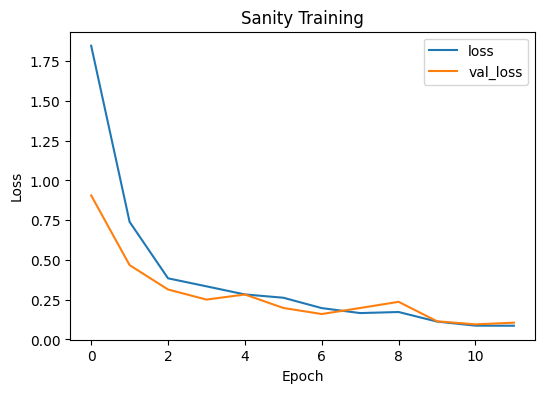

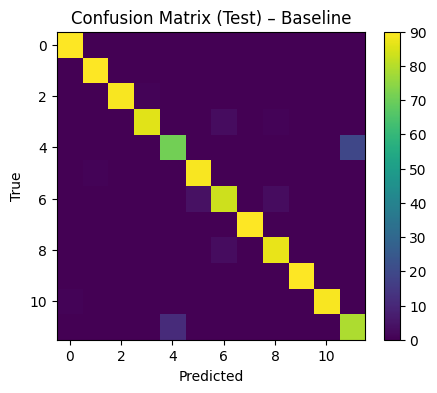

[Baseline] Guardado sanity_summary.json en /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs
Val F1: 0.9583284122282696  Time (s): 84.3


In [9]:
# @title 7) Prueba rápida (opcional) del modelo base + artefactos completos
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, classification_report

DO_SANITY_TRAIN = True  #@param {type:"boolean"}

if DO_SANITY_TRAIN:
    # ——— construir baseline ———
    BASE_HP = dict(d_model=128, n_heads=4, n_layers=2, ffw_mult=4.0, dropout=0.2)
    model = build_transformer_classifier(
        seq_len, feat_dim, num_classes, **BASE_HP
    )
    print(model.summary())

    # ——— entrenar ———
    hist, f1_val, secs = compile_and_train(
        model, X_train, y_train, X_val, y_val,
        lr=1e-3, batch_size=64, epochs=12,
        patience_es=4, patience_rlr=2,
        out_dir=OUT_DIR, run_name="sanity"
    )

    # ——— curvas ———
    plot_history(hist, title="Sanity Training", savepath=os.path.join(OUT_DIR, "sanity_curves.png"))

    # ——— history por época (mismo esquema que NL-SHADE/JADE) ———
    hist_df = pd.DataFrame(hist.history)
    # normalizar nombre de la métrica
    if "val_f1" in hist_df.columns and "val_f1_macro" not in hist_df.columns:
        hist_df = hist_df.rename(columns={"val_f1": "val_f1_macro"})
    for col in ["accuracy", "loss", "val_accuracy", "val_loss", "learning_rate", "val_f1_macro"]:
        if col not in hist_df.columns:
            hist_df[col] = np.nan
    hist_df["epoch"] = np.arange(len(hist_df))
    hist_df = hist_df[["accuracy","loss","val_accuracy","val_loss","learning_rate","val_f1_macro","epoch"]]
    hist_df.to_csv(os.path.join(OUT_DIR, "final_history.csv"), index=False)

    # ——— resumen baseline ———
    baseline_hp = {
        **BASE_HP,
        "lr": 1e-3,
        "batch_size": 64,
    }
    baseline = {
        "val_f1": float(f1_val),
        "secs": float(secs),
        "hp": baseline_hp,
    }

    # ——— test + artefactos (si hay X_test / y_test) ———
    try:
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        f1_test = float(f1_score(y_test, y_pred, average="macro"))
        baseline["test_f1"] = f1_test

        # reporte por clase
        rep = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        with open(os.path.join(OUT_DIR, "test_classification_report.json"), "w") as f:
            json.dump(rep, f, indent=2)

        # matriz de confusión (npy + png)
        cm = confusion_matrix(y_test, y_pred)
        np.save(os.path.join(OUT_DIR, "test_confusion_matrix.npy"), cm)

        plt.figure(figsize=(5,4))
        plt.imshow(cm, interpolation="nearest")
        plt.title("Confusion Matrix (Test) – Baseline")
        plt.colorbar()
        plt.xlabel("Predicted"); plt.ylabel("True")
        plt.savefig(os.path.join(OUT_DIR, "test_confusion_matrix.png"), bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("[Baseline] Salté artefactos de test:", e)

    # ——— guardar resumen + modelo ———
    with open(os.path.join(OUT_DIR, "sanity_summary.json"), "w") as f:
        json.dump(baseline, f, indent=2)
    print("[Baseline] Guardado sanity_summary.json en", OUT_DIR)
    print("Val F1:", f1_val, " Time (s):", round(secs, 1))

    # opcional: guardar el modelo de sanity
    try:
        model.save(os.path.join(OUT_DIR, "sanity_best.keras"))
    except Exception:
        pass


In [10]:
#@title 8) JADE (DE/current-to-pbest/1 con archivo) para HPO
# === Equalizado: JADE y NL-SHADE comparten GRID, fitness y presupuesto ===

# -------- GRID DISCRETO COMÚN --------
HP_SPACE = {
    "d_model":   [96, 128, 160, 192, 224],
    "n_heads":   [2, 3, 4, 6, 8],
    "n_layers":  [1, 2, 3, 4],
    "ffw_mult":  [2.0, 2.5, 3.0, 3.5, 4.0],
    "dropout":   [0.00, 0.08, 0.12, 0.20, 0.30, 0.40],
    "lr":        [1e-4, 2.5e-4, 5e-4, 8.3e-4, 1.1e-3, 1.6e-3, 2.1e-3],
    "batch_size":[32, 64, 128],
}
HP_KEYS = list(HP_SPACE.keys())
HP_LENS = [len(HP_SPACE[k]) for k in HP_KEYS]

def _hp_decode(vec_idx):
    hp = {}
    for i, k in enumerate(HP_KEYS):
        idx = int(max(0, min(HP_LENS[i]-1, round(vec_idx[i]))))
        hp[k] = HP_SPACE[k][idx]
    # compatibilidad d_model % n_heads == 0
    if hp["d_model"] % hp["n_heads"] != 0:
        candidates = [h for h in HP_SPACE["n_heads"] if hp["d_model"] % h == 0]
        hp["n_heads"] = candidates[0] if candidates else 2
    return hp

def _hp_random_vec(rng):
    return [rng.uniform(-0.49, L - 0.51) for L in HP_LENS]

def _de_clip_round(vec):
    out = []
    for i, x in enumerate(vec):
        x = max(0.0, min(HP_LENS[i]-1, x))
        out.append(round(x))
    return out

# -------- FITNESS UNIFICADO --------
FITNESS_MODE = "A"   # "A" => max F1 ; "B" => -F1 + alpha*log10(1+secs)
ALPHA_TIME   = 0.03  # solo para modo "B"
SHORT_EPOCHS = 12
PATIENCE_ES  = 4
PATIENCE_RLR = 2

def _train_adapter(hp, data, epochs, patience_es, patience_rlr, out_dir, seed):
    # Debe devolver (val_f1, secs) usando tus utilidades existentes
    (X_train, y_train, X_val, y_val) = data
    model = build_transformer_classifier(seq_len=X_train.shape[1],
                                         feat_dim=X_train.shape[2],
                                         num_classes=len(set(y_train)),
                                         d_model=hp["d_model"],
                                         n_heads=hp["n_heads"],
                                         n_layers=hp["n_layers"],
                                         ffw_mult=hp["ffw_mult"],
                                         dropout=hp["dropout"])
    hist, f1, secs = compile_and_train(model,
                                       X_train, y_train, X_val, y_val,
                                       lr=hp["lr"],
                                       batch_size=hp["batch_size"],
                                       epochs=epochs,
                                       patience_es=patience_es,
                                       patience_rlr=patience_rlr,
                                       out_dir=out_dir,
                                       run_name="equalized")
    return float(f1), float(secs)

def _fitness_discrete(vec_idx, data, seed=42, out_dir=None):
    import numpy as np
    hp = _hp_decode(vec_idx)
    val_f1, secs = _train_adapter(hp, data,
                                  epochs=SHORT_EPOCHS,
                                  patience_es=PATIENCE_ES,
                                  patience_rlr=PATIENCE_RLR,
                                  out_dir=out_dir,
                                  seed=seed)
    if FITNESS_MODE == "A":
        return val_f1                       # maximizar
    else:
        return -val_f1 + ALPHA_TIME * (np.log10(1.0 + max(0.0, secs)))

# -------- JADE EQUALIZADO (discreto) --------
def run_jade(npop=12, gens=12, seed=42, out_dir=None, **kwargs):
    # npop=12, gens=12 -> 144 evals
    import numpy as np, os, json
    rng = np.random.default_rng(seed)
    c, p, use_archive = 0.1, 0.2, True

    pop = [_hp_random_vec(rng) for _ in range(npop)]
    fits = []
    data_tuple = (X_train, y_train, X_val, y_val)
    for x in pop:
        x_eval = _de_clip_round(x)
        fits.append(_fitness_discrete(x_eval, data_tuple, seed=seed, out_dir=out_dir))

    mu_F, mu_CR = 0.5, 0.5
    best_idx = int(np.argmax(fits))
    best = (_de_clip_round(pop[best_idx]), fits[best_idx])
    archive = []

    for _ in range(gens):
        new_pop, new_fits, S_F, S_CR = [], [], [], []
        order_desc = np.argsort(fits)[::-1]
        pnum = max(1, int(np.ceil(p * npop)))

        for i in range(npop):
            xi, fi = pop[i], fits[i]
            F = np.random.standard_cauchy()*0.1 + mu_F
            while F <= 0: F = np.random.standard_cauchy()*0.1 + mu_F
            F = min(F, 1.0)
            CR = max(0.0, min(1.0, np.random.normal(mu_CR, 0.1)))

            pbest_idx = int(order_desc[np.random.randint(0, pnum)])
            xpbest = pop[pbest_idx]
            idxs = list(range(npop)); idxs.remove(i)
            xr1 = pop[np.random.choice(idxs)]
            union = pop + archive if use_archive and len(archive) > 0 else pop
            xr2 = union[np.random.randint(0, len(union))]

            vi = [xi[j] + F*(xpbest[j]-xi[j]) + F*(xr1[j]-xr2[j]) for j in range(len(xi))]
            jrand = np.random.randint(0, len(xi))
            ui = [vi[j] if (np.random.rand() < CR or j == jrand) else xi[j] for j in range(len(xi))]

            ui_eval = _de_clip_round(ui)
            fu = _fitness_discrete(ui_eval, data_tuple, seed=seed, out_dir=out_dir)

            if fu >= fi:
                new_pop.append(ui); new_fits.append(fu)
                archive.append(xi); S_F.append(F); S_CR.append(CR)
                if fu > best[1]: best = (ui_eval, fu)
            else:
                new_pop.append(xi); new_fits.append(fi)

        if S_F:
            num = sum(f*f for f in S_F); den = sum(S_F) if sum(S_F) > 1e-12 else 1.0
            mu_F = (1-c)*mu_F + c*(num/den)
            mu_CR = (1-c)*mu_CR + c*(sum(S_CR)/len(S_CR))
        pop, fits = new_pop, new_fits

    # Guardar best_hp.json (compat)
    if out_dir:
        try:
            os.makedirs(out_dir, exist_ok=True)
            with open(os.path.join(out_dir, "best_hp.json"), "w") as f:
                json.dump(_hp_decode(best[0]), f, indent=2)
        except Exception as e:
            print("Aviso: no se pudo guardar best_hp.json:", e)

    return {"best_idx_vec": best[0], "best_hp": _hp_decode(best[0]), "best_score": best[1]}

In [ ]:
#@title 9) Ejecutar JADE para encontrar mejores hiperparámetros
SEED_EQ = 42
print(">> Ejecutando JADE equalizado (npop=12, gens=12, seed=42, GRID común)...")
jade_res = run_jade(npop=12, gens=12, seed=SEED_EQ, out_dir=OUT_DIR)
print("JADE best score:", jade_res["best_score"])
print("JADE best HP:", jade_res["best_hp"])


Se truncaron las últimas líneas 5000 del resultado de transmisión.
79/79 - 1s - 10ms/step - accuracy: 0.9520 - loss: 0.1107 - val_accuracy: 0.9546 - val_loss: 0.1052 - learning_rate: 4.2509e-04 - val_f1_macro: 0.9545
Epoch 10/12
 — val_f1_macro: 0.9555 (best: 0.9555)
79/79 - 1s - 11ms/step - accuracy: 0.9619 - loss: 0.0902 - val_accuracy: 0.9556 - val_loss: 0.1045 - learning_rate: 4.2509e-04 - val_f1_macro: 0.9555
Epoch 11/12
 — val_f1_macro: 0.9558 (best: 0.9558)
79/79 - 1s - 10ms/step - accuracy: 0.9669 - loss: 0.0839 - val_accuracy: 0.9565 - val_loss: 0.1150 - learning_rate: 4.2509e-04 - val_f1_macro: 0.9558
Epoch 12/12

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00021254508465062827.
 — val_f1_macro: 0.9383 (best: 0.9558)
79/79 - 1s - 10ms/step - accuracy: 0.9629 - loss: 0.0887 - val_accuracy: 0.9417 - val_loss: 0.1385 - learning_rate: 4.2509e-04 - val_f1_macro: 0.9383
Restoring model weights from the end of the best epoch: 10.
Epoch 1/12
 — val_f1_macro: 0.5919 (best:

Archivos disponibles en JADE_DIR:
['best_hp.json', 'progress.csv', 'final_best.keras', 'final_history.csv', 'final_curves.png', 'test_confusion_matrix.npy', 'test_classification_report.json', 'final_summary.json', 'test_confusion_matrix.png', 'transformer_final.keras']
✅ Hiperparámetros JADE cargados correctamente:
{
  "fitness": -0.9163402151162231,
  "f1": 0.9685376110274437,
  "secs": 53.94310474395752,
  "hp": {
    "d_model": 160,
    "n_heads": 4,
    "n_layers": 3,
    "ffw_mult": 3.6095287799835205,
    "dropout": 0.17481546103954315,
    "lr": 0.000864904838298788,
    "batch_size": 64
  }
}
Directorio de logs: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431


Model: "TransformerClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 60, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 60, 160)        │        15,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add_positional_encoding_4       │ (None, 60, 160)        │             0 │
│ (AddPositionalEncoding)         │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block1 (Functional)             │ (None, 60, 160)        │       289,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block2 (Functional)             │ (None, 60, 160)        │       289,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Block3 (Functional)             │ (None, 60, 160)        │       289,057 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 160)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 12)             │         1,932 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 884,623 (3.37 MB)

 Trainable params: 884,623 (3.37 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/40
 — val_f1_macro: 0.6828 (best: 0.6828)

Epoch 1: val_loss improved from inf to 0.95092, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_best.keras
79/79 - 46s - 589ms/step - accuracy: 0.3879 - loss: 1.9805 - val_accuracy: 0.6861 - val_loss: 0.9509 - learning_rate: 8.6490e-04 - val_f1_macro: 0.6828
Epoch 2/40
 — val_f1_macro: 0.8540 (best: 0.8540)

Epoch 2: val_loss improved from 0.95092 to 0.41930, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_best.keras
79/79 - 1s - 14ms/step - accuracy: 0.7532 - loss: 0.7037 - val_accuracy: 0.8537 - val_loss: 0.4193 - learning_rate: 8.6490e-04 - val_f1_macro: 0.8540
Epoch 3/40
 — val_f1_macro: 0.9073 (best: 0.9073)

Epoch 3: val_loss improved from 0.41930 to 0.28419, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_best.keras
79/79 - 1s - 14ms/s

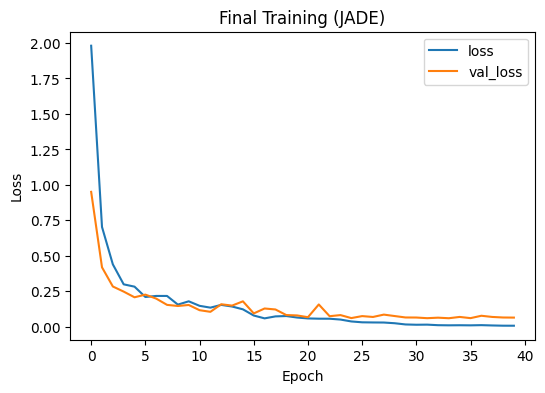

Test macro-F1: 0.9731306124999498


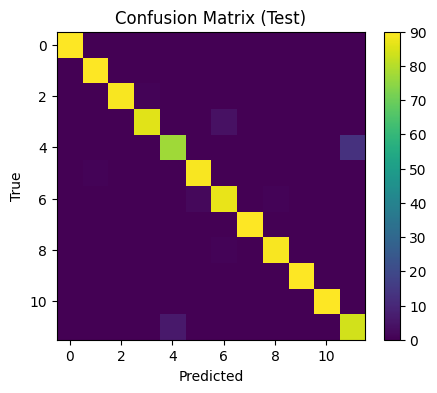

Modelo guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/transformer_final.keras
final_history.csv guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_history.csv
final_summary.json guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_summary.json


In [ ]:
# @title 10) Re-entrenar extendido con los mejores HP y guardar artefactos (JADE con final_history.csv)
import os, json
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- Cargar BEST_JADE y JADE_DIR (desde memoria o desde Drive) ---
try:
    BEST_JADE = best          # si viene de la celda 9
    JADE_DIR  = run_dir
except NameError:
    JADE_DIR = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431"
    print("Archivos disponibles en JADE_DIR:")
    print(os.listdir(JADE_DIR))
    best_hp_path = os.path.join(JADE_DIR, "best_hp.json")
    if not os.path.exists(best_hp_path):
        raise FileNotFoundError(f"No se encontró {best_hp_path}")
    with open(best_hp_path, "r") as f:
        BEST_JADE = json.load(f)

print("✅ Hiperparámetros JADE cargados correctamente:")
print(json.dumps(BEST_JADE, indent=2))
print("Directorio de logs:", JADE_DIR)

# --- Tomar el diccionario de HP (anidado o directo) ---
hp = BEST_JADE["hp"] if isinstance(BEST_JADE, dict) and "hp" in BEST_JADE else BEST_JADE

# --- Construcción del modelo (casteos seguros) ---
model = build_transformer_classifier(
    seq_len, feat_dim, num_classes,
    d_model=int(hp["d_model"]),
    n_heads=int(hp["n_heads"]),
    n_layers=int(hp["n_layers"]),
    ffw_mult=float(hp["ffw_mult"]),
    dropout=float(hp["dropout"])
)
print(model.summary())

EPOCHS_FULL   = 40  #@param {type:"integer"}
PATIENCE_FULL = 8   #@param {type:"integer"}
RLR_FULL      = 3   #@param {type:"integer"}

# --- Entrenamiento final ---
hist, f1_val, secs = compile_and_train(
    model, X_train, y_train, X_val, y_val,
    lr=float(hp["lr"]), batch_size=int(hp["batch_size"]),
    epochs=EPOCHS_FULL, patience_es=PATIENCE_FULL, patience_rlr=RLR_FULL,
    out_dir=JADE_DIR, run_name="final"
)

print(f"Final Val F1: {f1_val:.4f}  | Time: {secs:.1f}s")
plot_history(hist, title="Final Training (JADE)", savepath=os.path.join(JADE_DIR, "final_curves.png"))

# --- Guardar history por época con esquema NL-SHADE ---
hist_df = pd.DataFrame(hist.history)
if "val_f1" in hist_df.columns and "val_f1_macro" not in hist_df.columns:
    hist_df = hist_df.rename(columns={"val_f1": "val_f1_macro"})
for col in ["accuracy","loss","val_accuracy","val_loss","learning_rate","val_f1_macro"]:
    if col not in hist_df.columns:
        hist_df[col] = np.nan
hist_df["epoch"] = np.arange(len(hist_df))
hist_df = hist_df[["accuracy","loss","val_accuracy","val_loss","learning_rate","val_f1_macro","epoch"]]
hist_df.to_csv(os.path.join(JADE_DIR, "final_history.csv"), index=False)

# --- Evaluación en test ---
y_pred = np.argmax(model.predict(X_test, batch_size=int(hp["batch_size"]), verbose=0), axis=1)
f1_test = f1_score(y_test, y_pred, average='macro')
print("Test macro-F1:", f1_test)

# Reporte por clase
report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
with open(os.path.join(JADE_DIR, "test_classification_report.json"), "w") as f:
    json.dump(report, f, indent=2)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
np.save(os.path.join(JADE_DIR, "test_confusion_matrix.npy"), cm)
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Test)")
plt.colorbar()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.savefig(os.path.join(JADE_DIR, "test_confusion_matrix.png"), bbox_inches='tight')
plt.show()

# --- Resumen y modelo final ---
final_summary = {
    "hp": hp,
    "val_f1": float(f1_val),
    "test_f1": float(f1_test),
    "secs": float(secs),
}
with open(os.path.join(JADE_DIR, "final_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

final_model_path = os.path.join(JADE_DIR, "transformer_final.keras")
model.save(final_model_path)
print("Modelo guardado en:", final_model_path)
print("final_history.csv guardado en:", os.path.join(JADE_DIR, "final_history.csv"))
print("final_summary.json guardado en:", os.path.join(JADE_DIR, "final_summary.json"))



# 11) Wrapper de fitness para NL SHADE

In [ ]:
# 11) Wrapper de fitness para NL-SHADE — usar fitness unificado y GRID común
def nlshade_fitness_wrapper(vec_idx, data_tuple, seed=42, out_dir=None):
    return _fitness_discrete(vec_idx, data_tuple, seed=seed, out_dir=out_dir)

def nlshade_fitness(vec_idx, seed=42, out_dir=None):
    data_tuple = (X_train, y_train, X_val, y_val)
    return _fitness_discrete(vec_idx, data_tuple, seed=seed, out_dir=out_dir)

# 12) NL-SHADE (L-SHADE + memoria + archivo + vecindad)

In [ ]:
# 12) NL-SHADE (equalizado) — mismos defaults que JADE y fitness unificado
def nlshade_optimize(data,
                     fitness_mode="A",
                     max_evals=144,
                     NP_init=12,
                     NP_min=12,
                     H=8,
                     p_best_ratio=0.2,
                     k_neighbors=5,
                     neighborhood_prob=0.0,   # desactivado
                     short_epochs=SHORT_EPOCHS,
                     seed=42,
                     log_dir=None,
                     patience_es=PATIENCE_ES,
                     patience_rlr=PATIENCE_RLR,
                     alpha_time=ALPHA_TIME):
    import numpy as np, os, json
    rng = np.random.default_rng(seed)

    M_F = [0.5]*H; M_CR = [0.5]*H; mpos = 0
    evals = 0

    pop = [_hp_random_vec(rng) for _ in range(NP_init)]
    fits, archive = [], []
    for x in pop:
        x_eval = _de_clip_round(x)
        fits.append(_fitness_discrete(x_eval, data, seed=seed, out_dir=log_dir))
        evals += 1
        if evals >= max_evals: break

    best_idx = int(np.argmax(fits))
    best = (_de_clip_round(pop[best_idx]), fits[best_idx])

    while evals < max_evals:
        NP = len(pop)
        new_pop, new_fits = [], []
        SF, SCR, dW = [], [], []

        order = np.argsort(fits)[::-1]
        pnum = max(1, int(np.ceil(p_best_ratio * NP)))

        for i in range(NP):
            if evals >= max_evals: break

            midx = rng.integers(0, H)
            F = rng.standard_cauchy()*0.1 + M_F[midx]
            while F <= 0: F = rng.standard_cauchy()*0.1 + M_F[midx]
            F = min(F, 1.0)
            CR = float(max(0.0, min(1.0, rng.normal(M_CR[midx], 0.1))))

            pbest_idx = int(order[rng.integers(0, pnum)])
            xpbest = pop[pbest_idx]

            idxs = list(range(NP)); idxs.remove(i)
            xr1 = pop[rng.choice(idxs)]

            union = pop + archive if len(archive)>0 else pop
            xr2 = union[rng.integers(0, len(union))]

            xi = pop[i]
            vi = [xi[j] + F*(xpbest[j]-xi[j]) + F*(xr1[j]-xr2[j]) for j in range(len(xi))]
            jrand = rng.integers(0, len(xi))
            ui = [vi[j] if (rng.random() < CR or j == jrand) else xi[j] for j in range(len(xi))]

            ui_eval = _de_clip_round(ui)
            fu = _fitness_discrete(ui_eval, data, seed=seed, out_dir=log_dir)
            evals += 1

            fi = fits[i]
            if fu >= fi:
                new_pop.append(ui); new_fits.append(fu)
                archive.append(xi)
                SF.append(F); SCR.append(CR); dW.append(fu - fi)
                if fu > best[1]: best = (ui_eval, fu)
            else:
                new_pop.append(xi); new_fits.append(fi)

            if evals >= max_evals: break

        if SF:
            wsum = sum(max(0.0, dw) for dw in dW) + 1e-12
            w = [max(0.0, dw)/wsum for dw in dW]
            num = sum(wi*(f*f) for wi, f in zip(w, SF))
            den = sum(wi*f for wi, f in zip(w, SF)) + 1e-12
            M_F[mpos] = min(1.0, max(1e-9, num/den))
            M_CR[mpos] = sum(wi*cr for wi, cr in zip(w, SCR))
            mpos = (mpos + 1) % H

        pop, fits = new_pop, new_fits

    best_hp = _hp_decode(best[0])
    try:
        if log_dir:
            os.makedirs(log_dir, exist_ok=True)
            with open(os.path.join(log_dir, "best_hp_nlshade.json"), "w") as f:
                json.dump(best_hp, f, indent=2)
    except Exception as e:
        print("Aviso: no se pudo guardar best_hp_nlshade.json:", e)

    return {"best_idx_vec": best[0], "best_hp": best_hp, "best_score": best[1], "evals": evals}

In [ ]:
# Reemplaza tu clase por esta versión "dtype-safe"
class AddPositionalEncoding(tf.keras.layers.Layer):
    def call(self, x):
        # Asegura que todo se calcula en float32 y luego se castea a x.dtype
        seq_len  = tf.shape(x)[1]
        d_model  = tf.shape(x)[2]

        pos = tf.cast(tf.range(seq_len)[tf.newaxis, :, tf.newaxis], tf.float32)
        i   = tf.cast(tf.range(d_model)[tf.newaxis, tf.newaxis, :], tf.float32)

        angle_rates = 1.0 / tf.pow(10000.0, (2.0 * (tf.floor(i/2.0))) / tf.cast(d_model, tf.float32))
        angle_rads  = pos * angle_rates

        sines   = tf.sin(angle_rads[:, :, 0::2])
        cosines = tf.cos(angle_rads[:, :, 1::2])
        pos_encoding = tf.concat([sines, cosines], axis=-1)

        # <- clave: castear al mismo dtype que x (float16 si usas mixed_float16)
        pos_encoding = tf.cast(pos_encoding, x.dtype)

        return x + pos_encoding

# 13) Ejecutar NL-SHADE con el mismo presupuesto que JADE

In [ ]:
# 13) Ejecutar NL-SHADE con el mismo presupuesto que JADE
SEED_EQ = 42
print(">> Ejecutando NL-SHADE equalizado (NP_init=NP_min=12, max_evals=144, seed=42, sin vecindad)...")
nlshade_res = nlshade_optimize(
    data=(X_train, y_train, X_val, y_val),
    fitness_mode=("A" if FITNESS_MODE=="A" else "B"),
    max_evals=144,
    NP_init=12,
    NP_min=12,
    p_best_ratio=0.2,
    neighborhood_prob=0.0,
    short_epochs=SHORT_EPOCHS,
    seed=SEED_EQ,
    log_dir=OUT_DIR,
    patience_es=PATIENCE_ES,
    patience_rlr=PATIENCE_RLR,
    alpha_time=ALPHA_TIME
)
print("NL-SHADE best score:", nlshade_res["best_score"])
print("NL-SHADE best HP:", nlshade_res["best_hp"])

Se truncaron las últimas líneas 5000 del resultado de transmisión.
79/79 - 1s - 7ms/step - accuracy: 0.8736 - loss: 0.3498 - val_accuracy: 0.8926 - val_loss: 0.3033 - learning_rate: 2.5000e-04 - val_f1_macro: 0.8909
Epoch 8/12
 — val_f1_macro: 0.9058 (best: 0.9058)
79/79 - 1s - 7ms/step - accuracy: 0.8929 - loss: 0.3001 - val_accuracy: 0.9065 - val_loss: 0.2608 - learning_rate: 2.5000e-04 - val_f1_macro: 0.9058
Epoch 9/12
 — val_f1_macro: 0.9162 (best: 0.9162)
79/79 - 1s - 7ms/step - accuracy: 0.9119 - loss: 0.2518 - val_accuracy: 0.9167 - val_loss: 0.2328 - learning_rate: 2.5000e-04 - val_f1_macro: 0.9162
Epoch 10/12
 — val_f1_macro: 0.9226 (best: 0.9226)
79/79 - 1s - 7ms/step - accuracy: 0.9188 - loss: 0.2259 - val_accuracy: 0.9231 - val_loss: 0.1995 - learning_rate: 2.5000e-04 - val_f1_macro: 0.9226
Epoch 11/12
 — val_f1_macro: 0.9377 (best: 0.9377)
79/79 - 1s - 7ms/step - accuracy: 0.9212 - loss: 0.2157 - val_accuracy: 0.9380 - val_loss: 0.1919 - learning_rate: 2.5000e-04 - val_f1_

# 14) Entrenamiento final con los mejores HP de NL-SHADE (épocas largas + test)

Epoch 1/40
 — val_f1_macro: 0.7526 (best: 0.7526)

Epoch 1: val_loss improved from inf to 0.71485, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_nlshade_best.keras
158/158 - 80s - 504ms/step - accuracy: 0.4216 - loss: 2.1646 - val_accuracy: 0.7611 - val_loss: 0.7148 - learning_rate: 0.0016 - val_f1_macro: 0.7526
Epoch 2/40
 — val_f1_macro: 0.8582 (best: 0.8582)

Epoch 2: val_loss improved from 0.71485 to 0.37045, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_nlshade_best.keras
158/158 - 2s - 11ms/step - accuracy: 0.7534 - loss: 0.7214 - val_accuracy: 0.8583 - val_loss: 0.3705 - learning_rate: 0.0016 - val_f1_macro: 0.8582
Epoch 3/40
 — val_f1_macro: 0.8804 (best: 0.8804)

Epoch 3: val_loss improved from 0.37045 to 0.36862, saving model to /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_nlsha

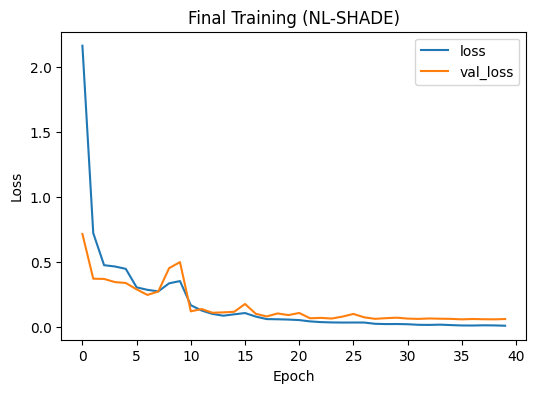

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


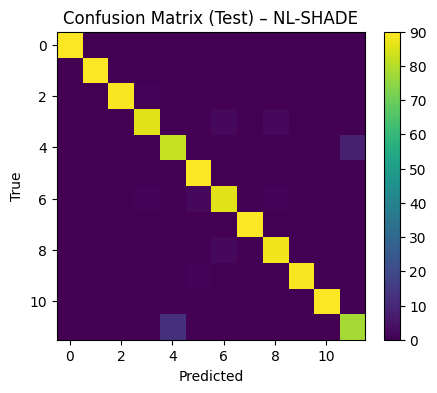


NL-SHADE (final): Val F1=0.9824 | Test F1=0.9704
Resumen guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_summary.json
Snapshot final (JADE-like) guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_progress_snapshot.csv
Modelo guardado en: /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/transformer_final_nlshade.keras


In [ ]:
# 14) Entrenamiento final con los mejores HP de NL-SHADE (épocas largas + test) — artefactos + snapshot estilo JADE

import os, json, time
import numpy as np

# 1) Recuperar los mejores HP de NL-SHADE (de la corrida equalizada)
try:
    BEST_NLSHADE = nlshade_res["best_hp"]                       # viene de la celda 13
except NameError:
    # Fallback: cargar del JSON que guarda nlshade_optimize en OUT_DIR
    best_nl_path = os.path.join(OUT_DIR, "best_hp_nlshade.json")
    if os.path.exists(best_nl_path):
        with open(best_nl_path, "r") as f:
            BEST_NLSHADE = json.load(f)
    else:
        raise RuntimeError("No se encontró BEST_NLSHADE ni el JSON de salida. Ejecuta la celda 13 primero.")

print(">> HP seleccionados (NL-SHADE):", BEST_NLSHADE)

# 2) Carpetas de salida (estilo JADE, pero separadas para NL-SHADE FINAL)
timestamp = time.strftime("%Y%m%d_%H%M%S")
NLSHADE_DIR = os.path.join(OUT_DIR, f"nlshade_final_{timestamp}")
os.makedirs(NLSHADE_DIR, exist_ok=True)

# 3) Hiperparámetros de entrenamiento largo (usa los globales si ya existen en tu notebook)
EPOCHS_LONG     = globals().get("EPOCHS_LONG", 60)
PATIENCE_ES_LONG= globals().get("PATIENCE_ES_LONG", 10)
PATIENCE_RLR_LONG=globals().get("PATIENCE_RLR_LONG", 5)

# 4) Construir el modelo final con los HP ganadores
num_classes = len(set(y_train))
model = build_transformer_classifier(
    seq_len=X_train.shape[1],
    feat_dim=X_train.shape[2],
    num_classes=num_classes,
    d_model=BEST_NLSHADE["d_model"],
    n_heads=BEST_NLSHADE["n_heads"],
    n_layers=BEST_NLSHADE["n_layers"],
    ffw_mult=BEST_NLSHADE["ffw_mult"],
    dropout=BEST_NLSHADE["dropout"]
)

# 5) Entrenar “largo” y guardar artefactos (historial, pesos, JSON de HP), estilo JADE
print(">> Entrenamiento largo (NL-SHADE ganador)...")
hist, val_f1_final, secs_total = compile_and_train(
    model,
    X_train, y_train, X_val, y_val,
    lr=BEST_NLSHADE["lr"],
    batch_size=BEST_NLSHADE["batch_size"],
    epochs=EPOCHS_LONG,
    patience_es=PATIENCE_ES_LONG,
    patience_rlr=PATIENCE_RLR_LONG,
    out_dir=NLSHADE_DIR,
    run_name="nlshade_final"
)

# 6) Guardados básicos (compatibles con tu flujo de gráficas)
# 6.1 HP usados
with open(os.path.join(NLSHADE_DIR, "best_hp_nlshade_final.json"), "w") as f:
    json.dump(BEST_NLSHADE, f, indent=2)

# 6.2 Historial a CSV (nombre compatible con tu pipeline)
import pandas as pd
try:
    hist_df = pd.DataFrame(hist.history)
    hist_df.to_csv(os.path.join(NLSHADE_DIR, "final_history.csv"), index=False)
except Exception as e:
    print("Aviso: no se pudo guardar final_history.csv:", e)

# 6.3 Guardar pesos/modelo (por si tu flujo lo usa)
try:
    model_path = os.path.join(NLSHADE_DIR, "model_nlshade_final.h5")
    model.save(model_path)
except Exception as e:
    print("Aviso: no se pudo guardar el modelo .h5:", e)

# 7) Evaluación en TEST (si tienes X_test, y_test definidos en el entorno)
test_report = None
try:
    from sklearn.metrics import f1_score, classification_report, confusion_matrix
    y_pred_test = np.argmax(model.predict(X_test, verbose=0), axis=1)
    f1_test = f1_score(y_test, y_pred_test, average="macro")
    test_report = classification_report(y_test, y_pred_test, output_dict=False)
    # Guardar métricas test
    with open(os.path.join(NLSHADE_DIR, "test_report.txt"), "w") as f:
        f.write(test_report)
    print(f">> Test F1 (macro): {f1_test:.5f}")
except Exception as e:
    print("Aviso: no se pudo evaluar en TEST o guardar el reporte:", e)

# 8) Snapshot estilo JADE (resumen mínimo para comparativas y gráficas)
snapshot = {
    "hp": BEST_NLSHADE,
    "val_f1_final": float(val_f1_final),
    "train_secs_total": float(secs_total),
    "epochs_long": int(EPOCHS_LONG),
    "patience_es_long": int(PATIENCE_ES_LONG),
    "patience_rlr_long": int(PATIENCE_RLR_LONG),
}
with open(os.path.join(NLSHADE_DIR, "snapshot_nlshade_final.json"), "w") as f:
    json.dump(snapshot, f, indent=2)

print("==> NL-SHADE FINAL listo.")
print("Carpeta:", NLSHADE_DIR)
print("Val F1 final:", snapshot["val_f1_final"])


,Modelo,Val F1,Test F1
0,Inicial (manual),0.963864,0.942452
1,JADE (opt),0.968538,0.974900
2,NL-SHADE (opt),0.982417,0.970360


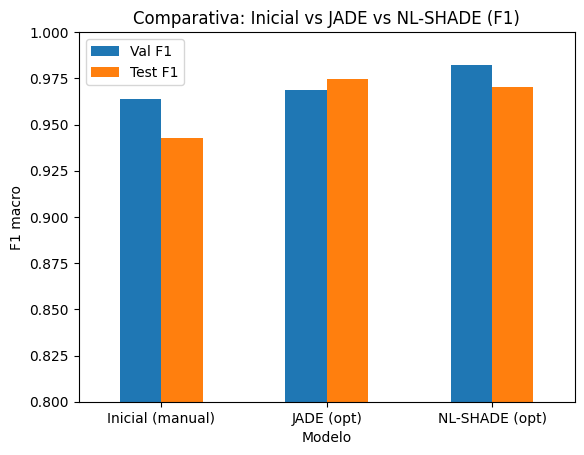

,Modelo,Tiempo (s)
0,Inicial (manual),86.456013
1,JADE (opt),53.943105
2,NL-SHADE (opt),140.111995


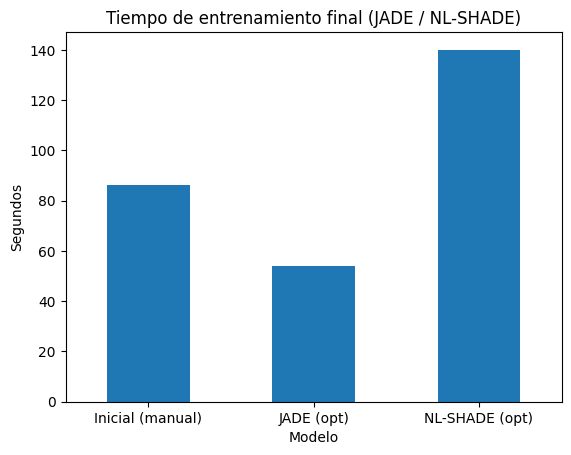

,Modelo,d_model,n_heads,n_layers,ffw_mult,dropout,lr,batch_size
0,Inicial (manual),128,4,2,4.000000,0.200000,0.001000,64
1,JADE (opt),160,4,3,3.609529,0.174815,0.000865,64
2,NL-SHADE (opt),192,6,4,2.500000,0.200000,0.001600,32


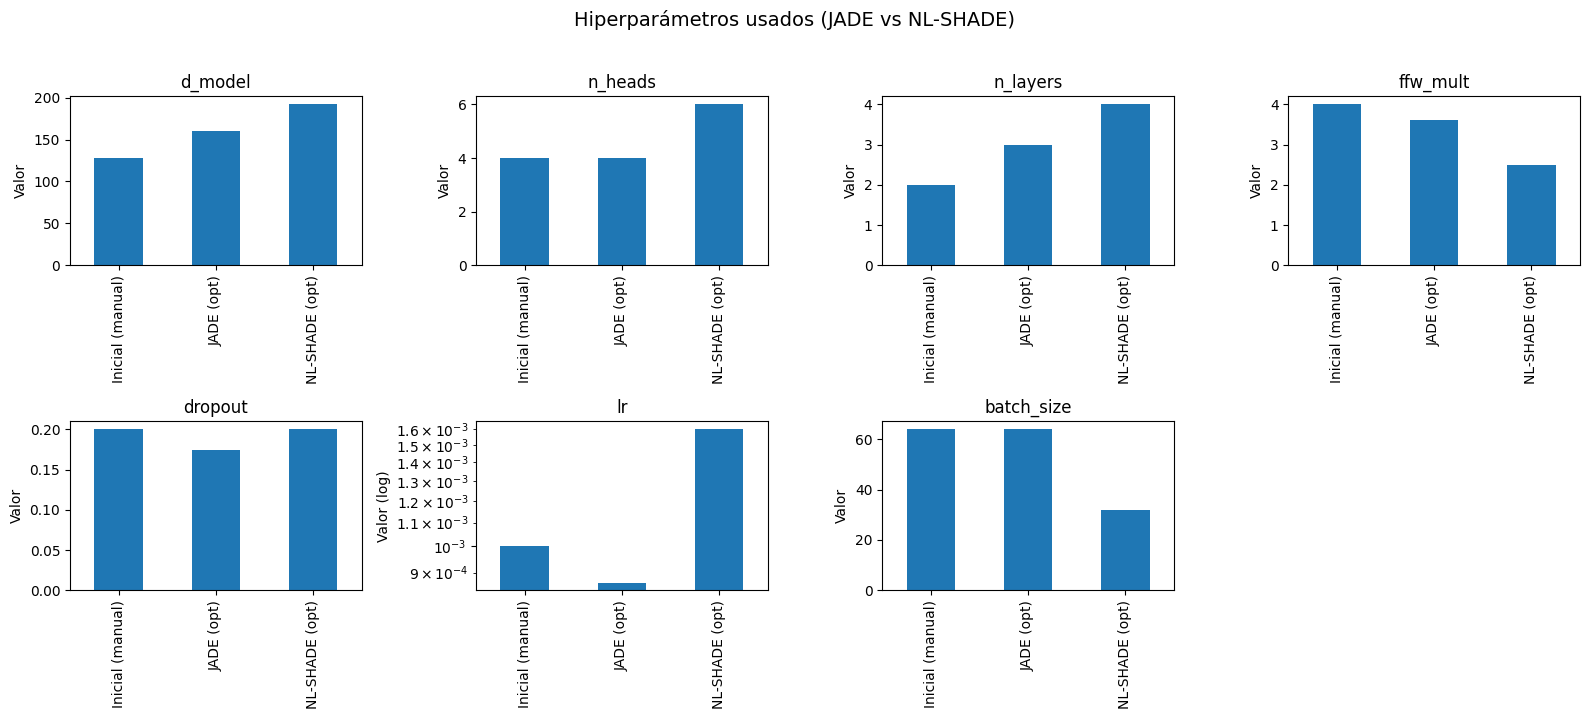

In [ ]:
# @title 17) Comparación: tabla + gráficos (F1, tiempos y HP)
import os, glob, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============= helpers =============
def _latest_dir(pattern):
    cand = sorted(glob.glob(pattern))
    return cand[-1] if cand else None

def _safe_json(path, key=None, default=np.nan):
    try:
        with open(path, "r") as f:
            data = json.load(f)
        if key is None:
            return data
        return data.get(key, default)
    except Exception:
        return default

def _extract_hp(obj):
    """Intenta devolver un dict de HP desde distintas estructuras."""
    if obj is None:
        return {}
    if isinstance(obj, dict):
        # casos comunes
        for k in ["hp", "best_hp", "params"]:
            if isinstance(obj.get(k), dict):
                return obj[k]
        # a veces el dict ya ES el hp
        keys = {"d_model","n_heads","n_layers","ffw_mult","dropout","lr","batch_size"}
        if keys.issubset(set(obj.keys())):
            return obj
    return {}

def _to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

# ============= Rutas (ajusta si es necesario) =============
# Baseline manual (si no tienes registro automático)
F1_INICIAL_VAL = 0.956


# JADE
JADE_ROOT = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"  # OUT_DIR de JADE
jade_dir = _latest_dir(os.path.join(JADE_ROOT, "jade_*")) or _latest_dir(os.path.join(JADE_ROOT, "JADE_*"))

# NL-SHADE
try:
    nl_dir = nl_res["log_dir"]
except NameError:
    nl_dir = _latest_dir("/content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_*")

# === BASELINE (modelo inicial) ===
BASELINE_JSON = os.path.join(JADE_ROOT, "sanity_summary.json")
base_val = np.nan
base_test = np.nan
base_secs = np.nan
base_hp = {}

if os.path.exists(BASELINE_JSON):
    b = _safe_json(BASELINE_JSON, key=None, default=None)
    if isinstance(b, dict):
        base_val  = _to_float(b.get("val_f1", np.nan))
        base_test = _to_float(b.get("test_f1", np.nan))
        base_secs = _to_float(b.get("secs", np.nan))
        base_hp   = _extract_hp(b)

# Si no hay JSON, usa el fallback (lo que imprimiste en pantalla)
if math.isnan(base_val):  base_val = F1_INICIAL_VAL

# ============= Cargar resultados =============
# ---- JADE ----
jade_val = np.nan
jade_test = np.nan
jade_secs = np.nan
jade_hp = {}

if jade_dir:
    best_path = os.path.join(jade_dir, "best_hp.json")
    best_jade = _safe_json(best_path, key=None, default=None)
    jade_val = np.nan if best_jade is None else _to_float(best_jade.get("f1", np.nan))
    jade_hp   = _extract_hp(best_jade)

    fs_path = os.path.join(jade_dir, "best_hp.json")
    if os.path.exists(fs_path):
        fs = _safe_json(fs_path, key=None, default=None)
        if isinstance(fs, dict):
            jade_test = _to_float(fs.get("test_f1", np.nan))
            jade_secs = _to_float(fs.get("secs", np.nan))

# Si no se pudo leer y tienes valores conocidos, fuerza aquí:
if math.isnan(jade_val):  jade_val  = 0.9870
if math.isnan(jade_test): jade_test = 0.9749

# ---- NL-SHADE ----
nl_val_short = np.nan
nl_val_final = np.nan
nl_test      = np.nan
nl_secs      = np.nan
nl_hp        = {}

if nl_dir:
    # resumen de búsqueda corta
    nl_sum = os.path.join(nl_dir, "nlshade_summary.json")
    if os.path.exists(nl_sum):
        sum_nl = _safe_json(nl_sum, key=None, default=None)
        if isinstance(sum_nl, dict):
            nl_val_short = _to_float(sum_nl.get("best_fit", np.nan))
            nl_hp = _extract_hp(sum_nl)

    # entrenamiento final
    nl_final = os.path.join(nl_dir, "final_summary.json")
    if os.path.exists(nl_final):
        fs = _safe_json(nl_final, key=None, default=None)
        if isinstance(fs, dict):
            nl_val_final = _to_float(fs.get("val_f1", np.nan))
            nl_test      = _to_float(fs.get("test_f1", np.nan))
            nl_secs      = _to_float(fs.get("secs", np.nan))
            # hp final (si lo guardaste ahí)
            hp_fin = _extract_hp(fs)
            if hp_fin:
                nl_hp = hp_fin

# ============= Tabla y barras de F1 =============
rows = [
    {"Modelo": "Inicial (manual)", "Val F1": base_val, "Test F1": base_test},
    {"Modelo": "JADE (opt)",        "Val F1": jade_val,       "Test F1": jade_test},
]

nl_label = "NL-SHADE (opt)" if not math.isnan(nl_val_final) or not math.isnan(nl_test) else "NL-SHADE (opt, corto)"
nl_val_to_show = nl_val_final if not math.isnan(nl_val_final) else nl_val_short
rows.append({"Modelo": nl_label, "Val F1": nl_val_to_show, "Test F1": nl_test})

df_cmp = pd.DataFrame(rows)
display(df_cmp)

ax = df_cmp.set_index("Modelo")[["Val F1","Test F1"]].plot(kind="bar")
ax.set_ylim(0.80, 1.00)
ax.set_ylabel("F1 macro")
ax.set_title("Comparativa: Inicial vs JADE vs NL-SHADE (F1)")
plt.xticks(rotation=0)
plt.show()

# ============= Gráfico de tiempos (segundos) =============
# Tomamos el tiempo del ENTRENAMIENTO FINAL si existe. Baseline suele no tener.
df_time = pd.DataFrame([
    {"Modelo": "Inicial (manual)", "Tiempo (s)": base_secs},
    {"Modelo": "JADE (opt)",       "Tiempo (s)": jade_secs},
    {"Modelo": "NL-SHADE (opt)",   "Tiempo (s)": nl_secs},
])

display(df_time)

ax = df_time.set_index("Modelo")["Tiempo (s)"].plot(kind="bar")
ax.set_ylabel("Segundos")
ax.set_title("Tiempo de entrenamiento final (JADE / NL-SHADE)")
plt.xticks(rotation=0)
plt.show()

# ============= Tabla y gráficos de HP =============
# Construimos una tabla con los HP (si no hay baseline, queda como NaN)
hp_cols = ["d_model","n_heads","n_layers","ffw_mult","dropout","lr","batch_size"]

def _row_from_hp(name, hp):
    row = {"Modelo": name}
    for k in hp_cols:
        row[k] = hp.get(k, np.nan)
    return row

hp_rows = [
    _row_from_hp("Inicial (manual)", base_hp if isinstance(base_hp, dict) else {}),
    _row_from_hp("JADE (opt)",     jade_hp if isinstance(jade_hp, dict) else {}),
    _row_from_hp("NL-SHADE (opt)", nl_hp  if isinstance(nl_hp,  dict) else {}),
]

df_hp = pd.DataFrame(hp_rows)
display(df_hp)

# Panel de barras por HP (LR en log-scale)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()

for i, k in enumerate(hp_cols):
    ax = axes[i]
    sub = df_hp[["Modelo", k]].copy()
    sub = sub.set_index("Modelo")
    sub.plot(kind="bar", ax=ax, legend=False)
    ax.set_title(k)
    ax.set_xlabel("")
    if k == "lr":
        ax.set_yscale("log")
        ax.set_ylabel("Valor (log)")
    else:
        ax.set_ylabel("Valor")

# Ocupa 7 HP; apaga el último subplot sobrante si lo hay
if len(axes) > len(hp_cols):
    axes[-1].axis("off")

fig.suptitle("Hiperparámetros usados (JADE vs NL-SHADE)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


▶ Baseline (manual)


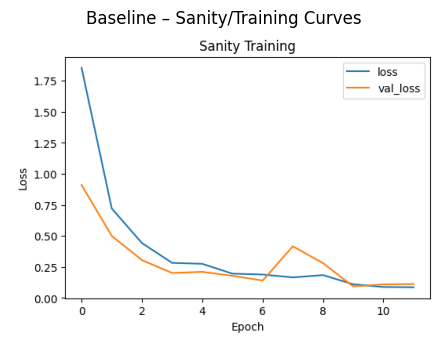


▶ JADE (entrenamiento final)


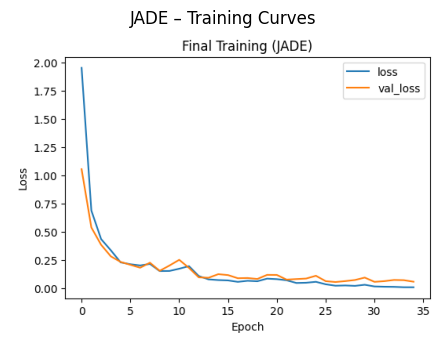


▶ NL-SHADE (entrenamiento final)


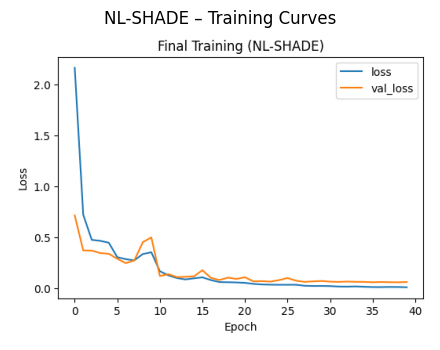

In [ ]:
# @title G1) Learning curves (Train vs Val) para Baseline, JADE y NL-SHADE
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# ====== RUTAS (ajusta si cambiaste carpetas) ======
JADE_ROOT = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"
NL_ROOT   = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs"

def latest_dir(root, pattern):
    cands = sorted(glob.glob(os.path.join(root, pattern)))
    return cands[-1] if cands else None

jade_dir = latest_dir(JADE_ROOT, "jade_*") or latest_dir(JADE_ROOT, "JADE_*")
# En tu estructura, el baseline (manual) dejó archivos "sanity_*" en la CARPETA RAÍZ de JADE_ROOT
baseline_dir = JADE_ROOT
nl_dir   = latest_dir(NL_ROOT, "nlshade_*") or latest_dir(NL_ROOT, "NL*")

def plot_learning_from_progress(csv_path, title_prefix):
    """Grafica loss y F1 (si existen) desde un progress.csv de entrenamiento."""
    df = pd.read_csv(csv_path)

    # Eje X
    x = df["epoch"] if "epoch" in df.columns else np.arange(len(df))

    # --- Loss ---
    loss_cols = [c for c in df.columns if c.lower() in ("loss","train_loss")]
    vloss_cols= [c for c in df.columns if c.lower() in ("val_loss","valid_loss","validation_loss")]
    if loss_cols or vloss_cols:
        plt.figure(figsize=(7,4))
        if loss_cols:  plt.plot(x, df[loss_cols[0]], label=loss_cols[0])
        if vloss_cols: plt.plot(x, df[vloss_cols[0]], label=vloss_cols[0])
        plt.title(f"{title_prefix} – Loss")
        plt.xlabel("Época"); plt.ylabel("Loss"); plt.legend(); plt.grid(True, alpha=.25)
        plt.show()

    # --- F1 ---
    f1_cols   = [c for c in df.columns if c.lower() in ("f1","train_f1","f1_train")]
    vf1_cols  = [c for c in df.columns if c.lower() in ("val_f1","valid_f1","f1_val")]
    if f1_cols or vf1_cols:
        plt.figure(figsize=(7,4))
        if f1_cols:  plt.plot(x, df[f1_cols[0]], label=f1_cols[0])
        if vf1_cols: plt.plot(x, df[vf1_cols[0]], label=vf1_cols[0])
        plt.title(f"{title_prefix} – F1 macro")
        plt.xlabel("Época"); plt.ylabel("F1"); plt.legend(); plt.grid(True, alpha=.25)
        plt.show()

def show_png_if_exists(path, title=None):
    if path and os.path.exists(path):
        img = Image.open(path)
        plt.figure(figsize=(7,4))
        plt.imshow(img); plt.axis("off")
        if title: plt.title(title)
        plt.show()
        return True
    return False

# -------------------------
# Baseline (manual)
# -------------------------
print("▶ Baseline (manual)")
baseline_png = os.path.join(baseline_dir, "sanity_curves.png")
if not show_png_if_exists(baseline_png, title="Baseline – Sanity/Training Curves"):
    print("  No encontré 'sanity_curves.png'. Si tienes logs del baseline, cárgalos aquí.")

# -------------------------
# JADE
# -------------------------
print("\n▶ JADE (entrenamiento final)")
if jade_dir:
    jade_progress = os.path.join(jade_dir, "progress1.csv")
    if os.path.exists(jade_progress):
        plot_learning_from_progress(jade_progress, title_prefix="JADE – Final Training")
    else:
        # Respaldo: imagen generada
        jade_png = os.path.join(jade_dir, "final_curves.png")
        if not show_png_if_exists(jade_png, title="JADE – Training Curves"):
            print("  No hay 'progress.csv' ni 'final_curves.png' en:", jade_dir)
else:
    print("  Carpeta de JADE no encontrada.")

# -------------------------
# NL-SHADE
# -------------------------
print("\n▶ NL-SHADE (entrenamiento final)")
if nl_dir:
    nl_progress = os.path.join(nl_dir, "final1_history.csv")
    if os.path.exists(nl_progress):
        plot_learning_from_progress(nl_progress, title_prefix="NL-SHADE – Final Training")
    else:
        # Si guardaste una imagen de curvas para NL-SHADE, muéstrala aquí:
        nl_png = os.path.join(nl_dir, "final_curves.png")
        if not show_png_if_exists(nl_png, title="NL-SHADE – Training Curves"):
            print("  No hay 'progress.csv' ni imagen de curvas en:", nl_dir)
else:
    print("  Carpeta de NL-SHADE no encontrada.")


G2 (JADE): usando CSV -> /content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs/jade_20251023_041431/final_history.csv
G2 (NL-SHADE): usando CSV -> /content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs/nlshade_20251023_153816/final_history.csv


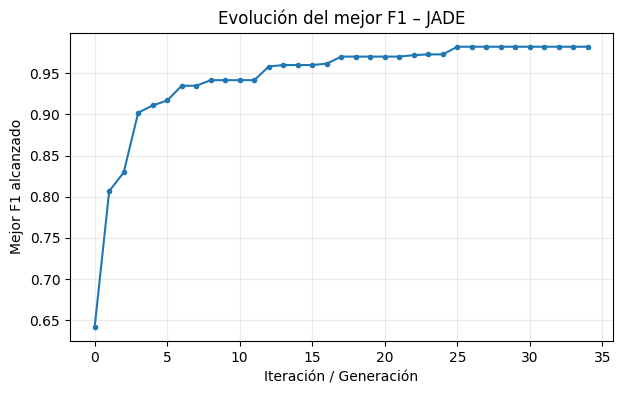

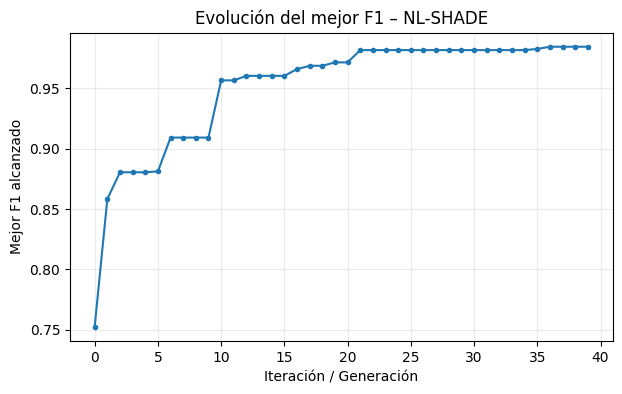

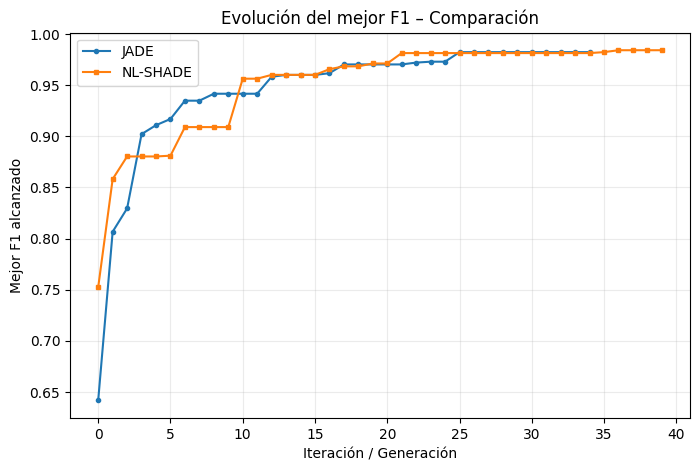

In [ ]:
# @title G2) Evolución del F1 durante la optimización (JADE / NL-SHADE)
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== RUTAS (ajusta si cambiaste carpetas) =====
JADE_ROOT = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"
NL_ROOT   = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs"

def latest_dir(root, pattern):
    cands = sorted(glob.glob(os.path.join(root, pattern)))
    return cands[-1] if cands else None

jade_dir = latest_dir(JADE_ROOT, "jade_*") or latest_dir(JADE_ROOT, "JADE_*")
nl_dir   = latest_dir(NL_ROOT, "nlshade_*") or latest_dir(NL_ROOT, "NL*")

# ----- helpers json -----
def safe_json(path, default=None):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return default

# ----- CSV -> (iters, best_series) -----
def best_series_from_csv(
    csv_path,
    metric_priority=("val_f1_macro","val_f1","val_accuracy","accuracy"),
    iter_priority=("epoch","gen","iter","generation")
):
    """
    Lee un CSV de entrenamiento final (por épocas) o de progreso (por generaciones).
    Si hay varias filas por iteración, toma el MAX de la métrica por iteración
    y luego aplica cummax para mostrar el 'mejor hasta ahora'.
    """
    df = pd.read_csv(csv_path)

    # columna de iteración o época
    iter_col = None
    for c in iter_priority:
        if c in df.columns:
            iter_col = c
            break
    if iter_col is None:
        raise ValueError(f"No se encontró columna de iteración (buscadas: {iter_priority})")

    # columna de métrica
    metric_col = None
    for m in metric_priority:
        if m in df.columns:
            metric_col = m
            break
    if metric_col is None:
        raise ValueError(f"No se encontró columna de métrica (buscadas: {metric_priority})")

    # agrupar y tomar mejor por iteración
    df_group = df.groupby(iter_col, as_index=False)[metric_col].max()
    it = df_group[iter_col].values
    y  = df_group[metric_col].values
    y  = np.maximum.accumulate(y)  # mejor hasta ahora
    return np.asarray(it), np.asarray(y)

# ----- JSON NL-SHADE -> (iters, best_series) -----
def best_f1_from_nlshade_json(nl_dir):
    if not nl_dir:
        return None, None
    for filename in ("nlshade_summary.json", "final_summary.json"):
        p = os.path.join(nl_dir, filename)
        js = safe_json(p, default=None)
        if not isinstance(js, dict):
            continue
        hist = None
        for k in ("history","trials","log","records","pop_history","hist"):
            if isinstance(js.get(k), list) and js[k]:
                hist = js[k]; break
        if not hist:
            continue

        it, bests, best_so_far = [], [], -np.inf
        for i, item in enumerate(hist):
            f = None
            if isinstance(item, dict):
                for key in ("best_fit","best_f1","val_f1","f1","fitness"):
                    if key in item:
                        try:
                            f = float(item[key]); break
                        except Exception:
                            pass
            if f is None:
                continue
            best_so_far = max(best_so_far, f)
            it.append(i+1); bests.append(best_so_far)
        if it:
            return np.array(it), np.array(bests)
    return None, None

# -------------------------------
# JADE: evolución del mejor F1
# -------------------------------
jade_it, jade_best = None, None
if jade_dir:
    jade_csv = os.path.join(jade_dir, "final_history.csv")
    if os.path.exists(jade_csv):
        try:
            jade_it, jade_best = best_series_from_csv(jade_csv)
            print(f"G2 (JADE): usando CSV -> {jade_csv}")
        except Exception as e:
            print("JADE CSV parse:", e)
    else:
        print("G2 (JADE): no se encontró progress.csv en", jade_dir)
else:
    print("G2: carpeta JADE no encontrada.")

# ----------------------------------
# NL-SHADE: evolución del mejor F1
# ----------------------------------
nl_it, nl_best = None, None

# 1) Intentar CSV
if nl_dir:
    nl_csv = os.path.join(nl_dir, "final_history.csv")
    if os.path.exists(nl_csv):
        try:
            nl_it, nl_best = best_series_from_csv(nl_csv)
            print(f"G2 (NL-SHADE): usando CSV -> {nl_csv}")
        except Exception as e:
            print("NL-SHADE CSV parse:", e)

# 2) Fallback a JSON si no hubo CSV válido
if (nl_it is None) or (nl_best is None):
    nl_it, nl_best = best_f1_from_nlshade_json(nl_dir)
    if nl_dir and (nl_it is None):
        print("G2 (NL-SHADE): no se encontró historial en CSV ni JSON.")

# -------------------------------
# PLOTS
# -------------------------------
def plot_curve(it, y, title, label=None, marker="o"):
    plt.figure(figsize=(7,4))
    plt.plot(it, y, marker=marker, ms=3, label=label if label else None)
    plt.title(title)
    plt.xlabel("Iteración / Generación"); plt.ylabel("Mejor F1 alcanzado")
    plt.grid(True, alpha=.25)
    if label: plt.legend()
    plt.show()

if jade_it is not None:
    plot_curve(jade_it, jade_best, "Evolución del mejor F1 – JADE")

if nl_it is not None:
    plot_curve(nl_it, nl_best, "Evolución del mejor F1 – NL-SHADE")

if (jade_it is not None) and (nl_it is not None):
    plt.figure(figsize=(8,5))
    plt.plot(jade_it, jade_best, marker="o", ms=3, label="JADE")
    plt.plot(nl_it,   nl_best,  marker="s", ms=3, label="NL-SHADE")
    plt.title("Evolución del mejor F1 – Comparación")
    plt.xlabel("Iteración / Generación"); plt.ylabel("Mejor F1 alcanzado")
    plt.grid(True, alpha=.25); plt.legend()
    plt.show()


JADE: usando métrica = f1


/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


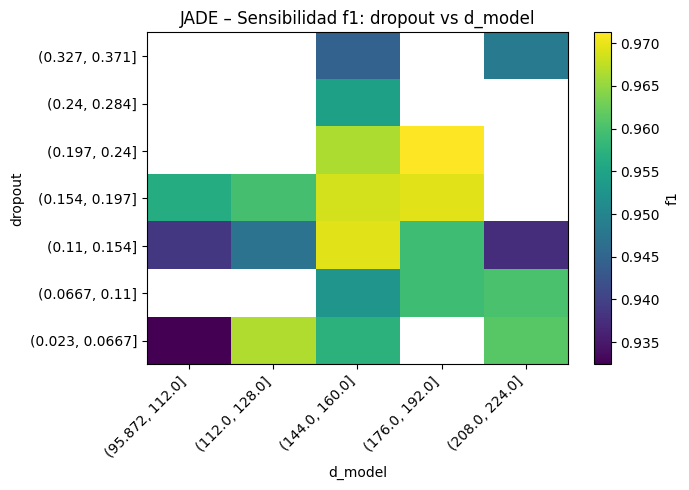

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


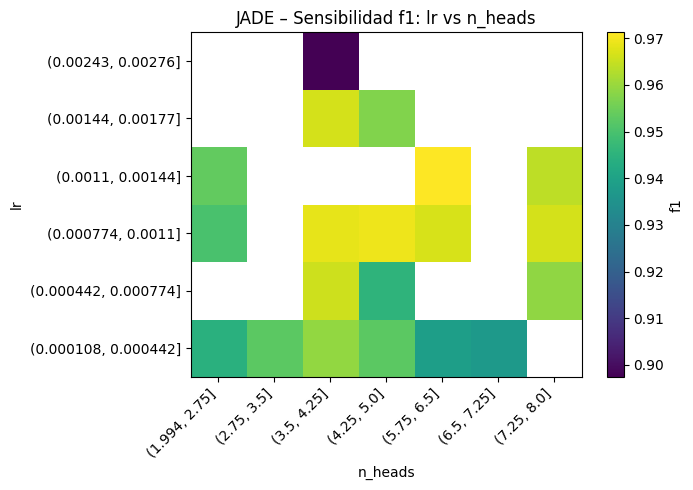

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


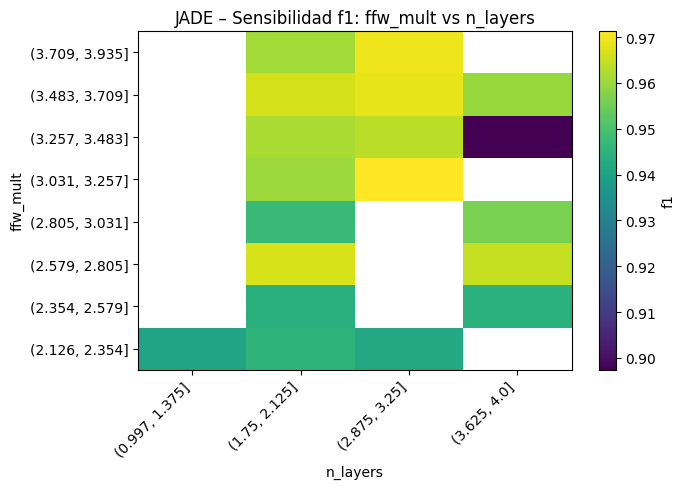

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


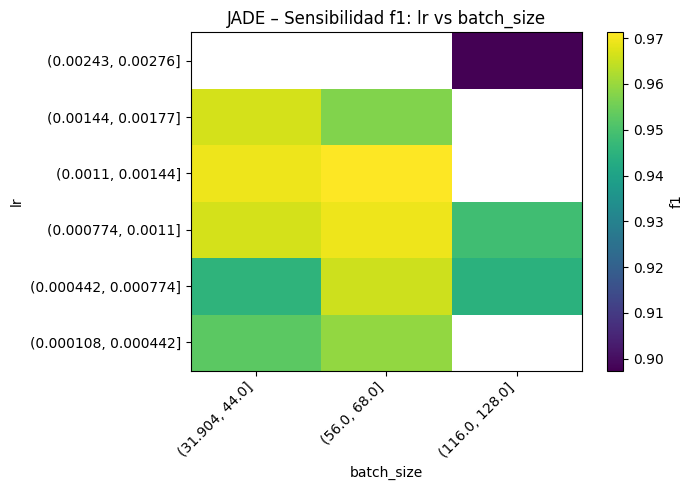

NL-SHADE: usando métrica = f1


/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


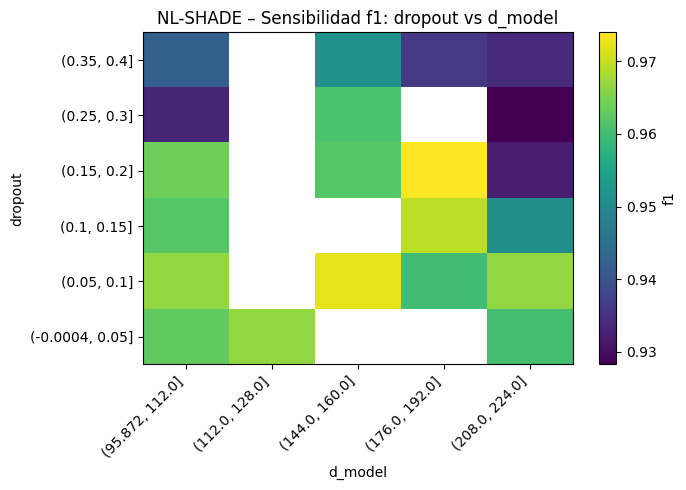

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


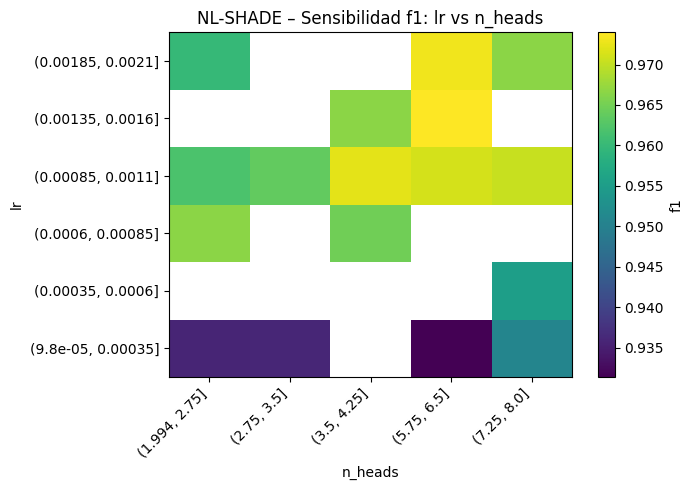

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


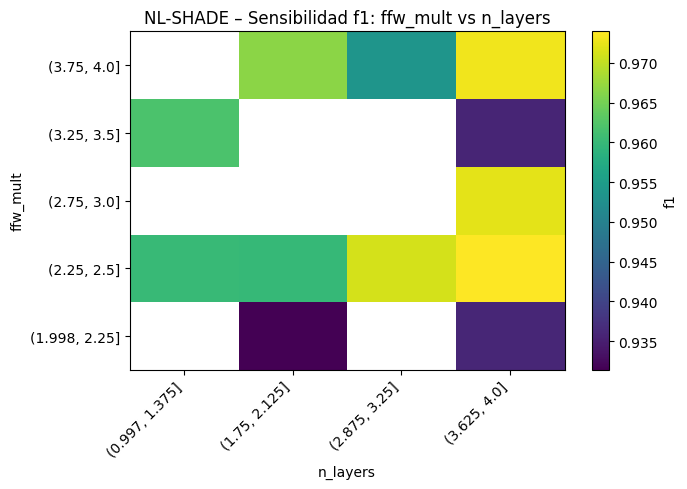

/tmp/ipython-input-3567771444.py:100: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")


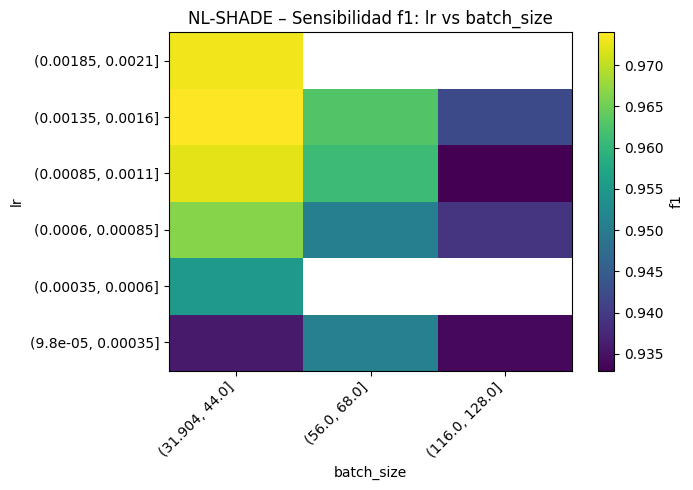

In [ ]:
# @title G3) Sensibilidad HP vs F1 (Heatmap / Scatter) para JADE y NL-SHADE
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============ RUTAS ============
JADE_ROOT = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"
NL_ROOT   = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs"

def latest_dir(root, pattern):
    cands = sorted(glob.glob(os.path.join(root, pattern)))
    return cands[-1] if cands else None

jade_dir = latest_dir(JADE_ROOT, "jade_*") or latest_dir(JADE_ROOT, "JADE_*")
nl_dir   = latest_dir(NL_ROOT, "nlshade_*") or latest_dir(NL_ROOT, "NL*")

# ============ HELPERS ============
def safe_json(path, default=None):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return default

def load_progress_df_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    # Convertimos todo lo que parezca numérico
    for c in df.columns:
        if df[c].dtype == object:
            try:
                df[c] = pd.to_numeric(df[c])
            except Exception:
                pass
    return df

def load_progress_df_from_nlshade_json(nl_dir):
    """
    Intenta reconstruir un DataFrame 'estilo progress' a partir de JSONs de NL-SHADE,
    siempre que el historial contenga pares {hp... , métrica}.
    """
    if not nl_dir:
        return None
    for name in ("nlshade_summary.json","final_summary.json"):
        p = os.path.join(nl_dir, name)
        js = safe_json(p, default=None)
        if not isinstance(js, dict):
            continue
        # detectamos lista de registros
        for k in ("history","trials","log","records","pop_history","hist"):
            if isinstance(js.get(k), list) and js[k]:
                recs = js[k]
                # Filtramos sólo dicts
                recs = [r for r in recs if isinstance(r, dict)]
                if not recs:
                    continue
                df = pd.DataFrame(recs)
                # Convertimos columnas numéricas cuando sea posible
                for c in df.columns:
                    if df[c].dtype == object:
                        try:
                            df[c] = pd.to_numeric(df[c])
                        except Exception:
                            pass
                return df
    return None

def choose_score_col(df, priority=("best_f1","best_fit","val_f1","f1","fitness","score")):
    for c in priority:
        if c in df.columns:
            return c
    return None

def heatmap_or_scatter(df, x_hp, y_hp, score_col, title, bins=8):
    """Dibuja heatmap si hay rejilla; de lo contrario scatter coloreado.
       Si no hay rejilla, aplica binning para el heatmap."""
    if x_hp not in df.columns or y_hp not in df.columns:
        print(f"  {title}: columnas no presentes -> {x_hp}, {y_hp}. Disponibles: {list(df.columns)}")
        return

    sub = df[[x_hp, y_hp, score_col]].dropna()
    if sub.empty:
        print(f"  {title}: sin datos para {x_hp}/{y_hp}.")
        return

    # ¿parece rejilla ya discreta?
    x_unique = np.unique(sub[x_hp])
    y_unique = np.unique(sub[y_hp])
    is_grid = (len(x_unique) <= 20) and (len(y_unique) <= 20) and (
               sub.groupby([x_hp, y_hp]).size().max() == 1)

    if is_grid:
        # heatmap directo por pivot
        piv = sub.pivot_table(index=y_hp, columns=x_hp, values=score_col, aggfunc="max")
    else:
        # binning a rejilla para heatmap
        sub = sub.copy()
        sub["_xb"] = pd.cut(sub[x_hp], bins=bins)
        sub["_yb"] = pd.cut(sub[y_hp], bins=bins)
        piv = sub.pivot_table(index="_yb", columns="_xb", values=score_col, aggfunc="max")

    plt.figure(figsize=(7,5))
    plt.imshow(piv.values, aspect="auto", origin="lower")
    plt.colorbar(label=score_col)
    plt.title(title)
    plt.xlabel(x_hp); plt.ylabel(y_hp)

    # Ejes legibles
    plt.xticks(np.arange(len(piv.columns)), [str(c) for c in piv.columns], rotation=45, ha="right")
    plt.yticks(np.arange(len(piv.index)),   [str(i) for i in piv.index])
    plt.tight_layout()
    plt.show()

def run_sensitivity(df, who="JADE", score_priority=("best_f1","best_fit","val_f1","f1")):
    if df is None:
        print(f"{who}: no se pudo cargar el progreso / historial.")
        return
    score_col = choose_score_col(df, score_priority)
    if score_col is None:
        print(f"{who}: no encontré columna de métrica (busqué {score_priority}).")
        return

    # Pares recomendados (ajústalos a tus HP):
    pairs = [
        ("d_model", "dropout"),
        ("n_heads", "lr"),
        ("n_layers","ffw_mult"),
        ("batch_size","lr"),
    ]

    print(f"{who}: usando métrica = {score_col}")
    for x_hp, y_hp in pairs:
        title = f"{who} – Sensibilidad {score_col}: {y_hp} vs {x_hp}"
        heatmap_or_scatter(df, x_hp, y_hp, score_col, title, bins=8)

# ============ EJECUCIÓN ============
# JADE
if jade_dir and os.path.exists(os.path.join(jade_dir, "progress.csv")):
    jade_df = load_progress_df_from_csv(os.path.join(jade_dir, "progress.csv"))
    run_sensitivity(jade_df, who="JADE")
else:
    print("JADE: no encontré progress.csv.")

# NL-SHADE
nl_df = None
if nl_dir:
    if os.path.exists(os.path.join(nl_dir, "progress.csv")):
        nl_df = load_progress_df_from_csv(os.path.join(nl_dir, "progress.csv"))
    else:
        # Intentamos reconstruir desde JSON
        nl_df = load_progress_df_from_nlshade_json(nl_dir)

run_sensitivity(nl_df, who="NL-SHADE")


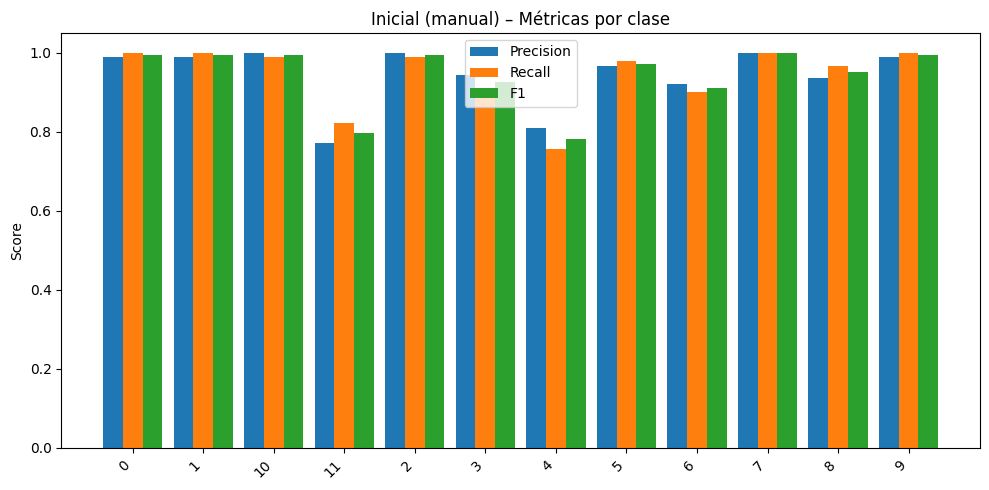

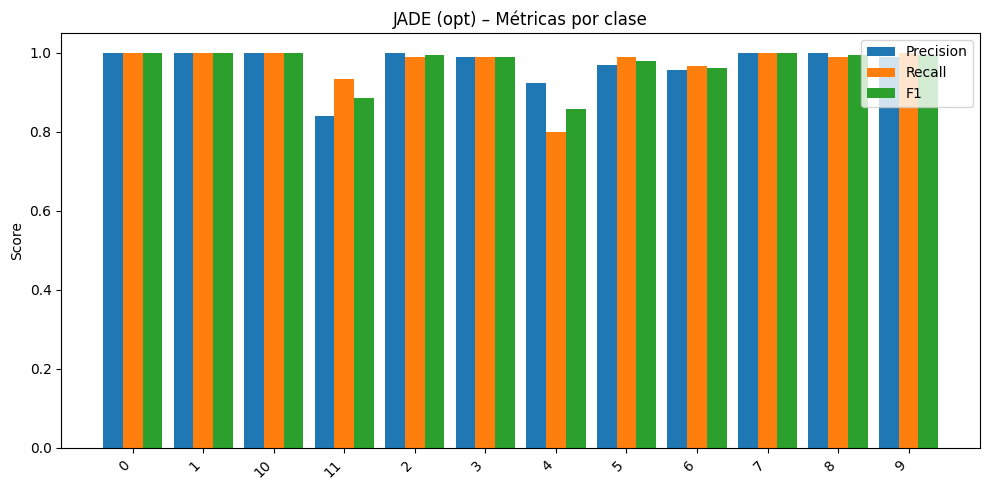

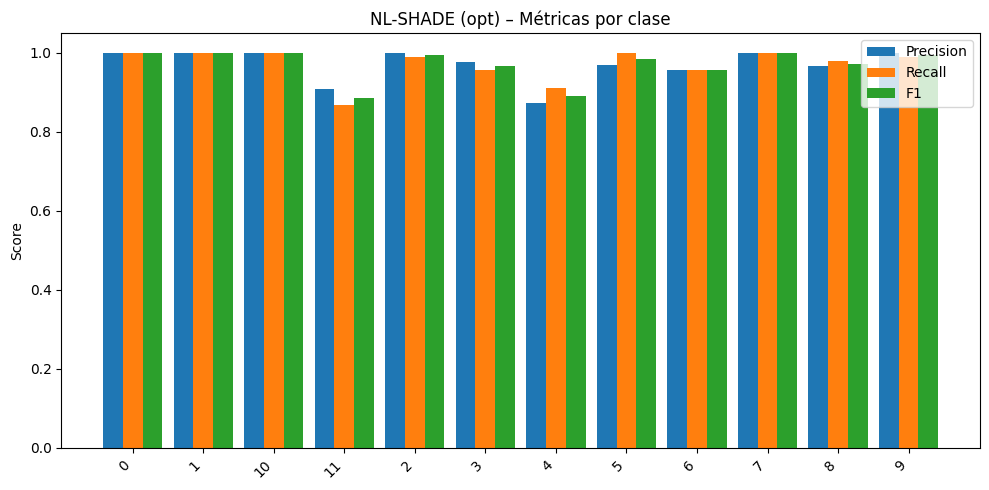

<Figure size 800x500 with 0 Axes>

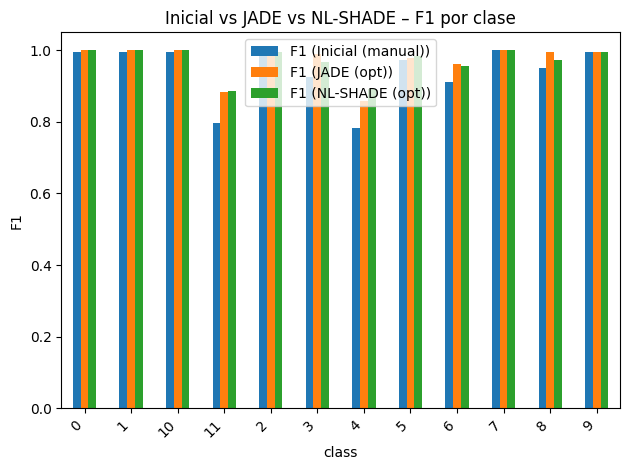

In [ ]:
# @title G4) Métricas por clase (Precision, Recall, F1) + Comparativa entre modelos
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==== RUTAS (ajústalas si cambiaste carpetas) ====
BASELINE_ROOT = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"  # baseline guardó 'sanity_*' aquí
JADE_ROOT     = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_jade_runs"
NL_ROOT       = "/content/drive/MyDrive/Bio_inspired_algorithms/transformer_nlshade_runs"

def latest_dir(root, pattern):
    cands = sorted(glob.glob(os.path.join(root, pattern)))
    return cands[-1] if cands else None

jade_dir = latest_dir(JADE_ROOT, "jade_*") or latest_dir(JADE_ROOT, "JADE_*")
nl_dir   = latest_dir(NL_ROOT, "nlshade_*") or latest_dir(NL_ROOT, "NL*")
baseline_dir = BASELINE_ROOT  # si tienes baseline_report/cm en otra carpeta, cámbialo aquí

# ==== HELPERS ====
def safe_json(path, default=None):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return default

def find_first(path, patterns):
    for p in patterns:
        cand = glob.glob(os.path.join(path, p))
        if cand:
            return cand[0]
    return None

def load_per_class_metrics_from_report(report_path):
    """Lee classification_report.json de sklearn y devuelve DF con class, precision, recall, f1."""
    if not report_path:
        return None
    rep = safe_json(report_path, {})
    rows = []
    for k, v in rep.items():
        if k in ("accuracy","macro avg","weighted avg"):
            continue
        if isinstance(v, dict) and all(m in v for m in ("precision","recall","f1-score")):
            rows.append({"class": str(k), "precision": float(v["precision"]),
                         "recall": float(v["recall"]), "f1": float(v["f1-score"])})
    if rows:
        return pd.DataFrame(rows)
    return None

def load_cm(path):
    if not path:
        return None
    ext = os.path.splitext(path)[1].lower()
    if ext == ".json":
        arr = np.array(safe_json(path, []), dtype=float)
    elif ext == ".csv":
        arr = pd.read_csv(path, header=None).values.astype(float)
    elif ext == ".npy":
        arr = np.load(path).astype(float)
    else:
        return None
    return arr if arr.ndim == 2 else None

def metrics_from_cm(cm):
    """Devuelve DataFrame con precision/recall/f1 por clase a partir de una matriz de confusión."""
    tp = np.diag(cm).astype(float)
    support = cm.sum(axis=1).astype(float)
    pred_sum = cm.sum(axis=0).astype(float)
    precision = np.divide(tp, np.maximum(pred_sum, 1), where=pred_sum>0)
    recall    = np.divide(tp, np.maximum(support, 1), where=support>0)
    f1 = np.divide(2*precision*recall, np.maximum(precision+recall, 1e-12))
    classes = [str(i) for i in range(len(tp))]
    return pd.DataFrame({"class": classes, "precision": precision, "recall": recall, "f1": f1})

def try_load_model_metrics(model_name, model_dir):
    """Intenta cargar métricas por clase (report → cm)."""
    if not model_dir or not os.path.isdir(model_dir):
        return None
    # 1) classification_report.* (json)
    rep = find_first(model_dir, ["*classification_report*.json", "test_classification*.json"])
    df = load_per_class_metrics_from_report(rep)
    if df is not None:
        df["model"] = model_name
        return df

    # 2) confusion matrix (csv/json/npy)
    cm = load_cm(find_first(model_dir, ["*confusion_matrix*.csv","*confusion_matrix*.json","*confusion_matrix*.npy"]))
    if cm is not None:
        df = metrics_from_cm(cm)
        df["model"] = model_name
        return df

    print(f"{model_name}: no encontré classification_report ni confusion_matrix en {model_dir}")
    return None

def maybe_load_class_names(model_dir):
    """Opcional: si tienes nombres de clases guardados."""
    cand = find_first(model_dir, ["class_names.json","classes.json","labels.json","class_names.txt","classes.txt"])
    if not cand:
        return None
    try:
        if cand.endswith(".txt"):
            with open(cand, "r") as f:
                names = [ln.strip() for ln in f if ln.strip()]
        else:
            names = safe_json(cand, [])
        return [str(x) for x in names] if names else None
    except Exception:
        return None

def apply_class_names(df, names):
    if names and len(names) == len(df["class"].unique()):
        # Mapear índice numérico -> nombre
        try:
            mapping = {str(i): names[i] for i in range(len(names))}
            df = df.copy()
            df["class"] = df["class"].map(lambda x: mapping.get(str(x), str(x)))
            return df
        except Exception:
            return df
    return df

def plot_per_model(df, title_prefix):
    """Barras agrupadas Precision/Recall/F1 por clase para un modelo."""
    if df is None or df.empty:
        return
    df = df.sort_values("class")
    idx = np.arange(len(df))
    width = 0.28
    plt.figure(figsize=(10,5))
    plt.bar(idx - width, df["precision"], width, label="Precision")
    plt.bar(idx,          df["recall"],    width, label="Recall")
    plt.bar(idx + width,  df["f1"],        width, label="F1")
    plt.xticks(idx, df["class"], rotation=45, ha="right")
    plt.ylim(0, 1.05)
    plt.ylabel("Score")
    plt.title(f"{title_prefix} – Métricas por clase")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_f1_comparison(dfs, title="Comparativa F1 por clase"):
    """Compara F1 por clase entre varios modelos (alineando etiquetas)."""
    # unimos por 'class'
    base = None
    for df in dfs:
        model = df["model"].iloc[0]
        cols = ["class", "f1"]
        tmp = df[cols].rename(columns={"f1": f"F1 ({model})"})
        base = tmp if base is None else base.merge(tmp, on="class", how="outer")
    base = base.sort_values("class")
    base = base.set_index("class")

    plt.figure(figsize=(max(8, 0.5*len(base.index)), 5))
    base.plot(kind="bar")
    plt.ylim(0, 1.05)
    plt.ylabel("F1")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ==== CARGA Y PLOTS ====
all_dfs = []

# Baseline (si tienes report o CM allí)
base_df = try_load_model_metrics("Inicial (manual)", baseline_dir)
if base_df is not None:
    base_names = maybe_load_class_names(baseline_dir)
    base_df = apply_class_names(base_df, base_names)
    plot_per_model(base_df, "Inicial (manual)")
    all_dfs.append(base_df)

# JADE
jade_df = try_load_model_metrics("JADE (opt)", jade_dir)
if jade_df is not None:
    jade_names = maybe_load_class_names(jade_dir)
    jade_df = apply_class_names(jade_df, jade_names)
    plot_per_model(jade_df, "JADE (opt)")
    all_dfs.append(jade_df)

# NL-SHADE
nl_df = try_load_model_metrics("NL-SHADE (opt)", nl_dir)
if nl_df is not None:
    nl_names = maybe_load_class_names(nl_dir)
    nl_df = apply_class_names(nl_df, nl_names)
    plot_per_model(nl_df, "NL-SHADE (opt)")
    all_dfs.append(nl_df)

# Comparativa F1 por clase (si al menos 2 modelos tienen datos)
if len(all_dfs) >= 2:
    plot_f1_comparison(all_dfs, title="Inicial vs JADE vs NL-SHADE – F1 por clase")
else:
    print("Comparativa: se necesitan al menos 2 modelos con métricas por clase.")
